In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
file=pd.read_csv('Life Expectancy Data - Life Expectancy Data.csv')

In [3]:
file.sample(10)

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
350,Botswana,2001,Developing,46.7,679.0,2,5.48,306.952735,87.0,1,...,97.0,5.73,97.0,37.2,3128.977930,1754935.0,11.8,11.8,0.560,11.8
2268,Serbia,2012,Developing,74.9,126.0,1,9.38,742.510971,97.0,0,...,93.0,9.89,91.0,0.1,5659.382400,719977.0,2.1,2.1,0.767,14.0
402,Burkina Faso,2013,Developing,59.0,27.0,40,4.64,88.970402,88.0,375,...,89.0,5.91,88.0,0.7,699.452847,1772723.0,8.4,7.9,0.392,7.5
2809,United States of America,2000,Developed,76.8,114.0,28,8.21,0.000000,9.0,85,...,9.0,13.70,94.0,0.1,NaN,NaN,0.8,0.7,NaN,NaN
1118,Guyana,2003,Developing,65.3,237.0,1,7.93,16.479490,9.0,0,...,91.0,5.97,9.0,2.1,986.795817,751857.0,5.8,5.6,0.611,11.1
770,Dominican Republic,2015,Developing,73.9,152.0,6,NaN,0.000000,81.0,0,...,87.0,NaN,85.0,0.3,6468.471648,1528394.0,3.3,3.2,0.718,13.2
338,Botswana,2013,Developing,64.2,286.0,2,0.01,1.117811,95.0,1,...,96.0,5.84,95.0,2.8,77.625783,212857.0,7.0,6.7,0.693,12.6
2167,Saint Kitts and Nevis,2013,Developing,NaN,NaN,0,8.54,0.000000,97.0,0,...,96.0,6.14,96.0,0.1,NaN,NaN,3.7,3.6,0.749,13.4
2034,Philippines,2004,Developing,67.3,218.0,66,4.45,13.399051,48.0,3025,...,85.0,3.23,88.0,0.1,179.371500,84678493.0,1.0,9.7,0.636,11.6
2137,Russian Federation,2013,Developing,70.0,229.0,14,10.58,1529.497771,97.0,2339,...,98.0,7.90,97.0,0.2,15543.676530,14356911.0,2.3,2.3,0.799,14.6


In [4]:

file.shape

(2938, 22)

In [5]:
file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10  BMI                              2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [6]:
file.isnull().sum()

,0
Country,0
Year,0
Status,0
Life expectancy,10
Adult Mortality,10
infant deaths,0
Alcohol,194
percentage expenditure,0
Hepatitis B,553
Measles,0


In [19]:
numerical_columns=file.select_dtypes(include=['number']).columns
len(numerical_columns)

20

In [20]:
for column in numerical_columns:
    file[column]=file[column].fillna(file[column].mean())

In [21]:
file.isnull().sum()

,0
Country,0
Year,0
Status,0
Life expectancy,0
Adult Mortality,0
infant deaths,0
Alcohol,0
percentage expenditure,0
Hepatitis B,0
Measles,0


In [22]:
# Feature selection
file['Adult Mortality'].corr(file['Life expectancy'])

np.float64(-0.6963593137699762)

In [26]:
file['Schooling'].corr(file['Life expectancy'])

np.float64(0.7150663398620056)

In [28]:
feature_variables=[]
for column in numerical_columns:
    if abs(file[column].corr(file['Life expectancy'])) > 0.65:
        feature_variables.append(column)
feature_variables.remove('Life expectancy')
feature_variables

['Adult Mortality', 'Income composition of resources', 'Schooling']

In [35]:
X=file[feature_variables]
y=file['Life expectancy']
print(X.shape)
print(y.shape)

(2938, 3)
(2938,)


In [36]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42
)

In [37]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42
)

In [39]:
model=LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [40]:
y_pred = model.predict(X_val)

mse = mean_squared_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

In [41]:
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared Score: {r2:.2f}")

Mean Squared Error: 26.27
R-squared Score: 0.73


<Axes: xlabel='Life expectancy'>

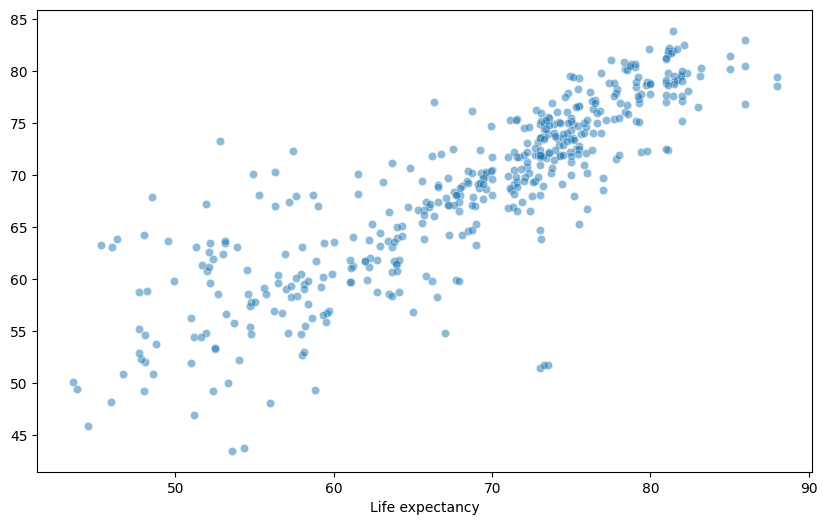

In [43]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_val, y=y_pred, alpha=0.5)

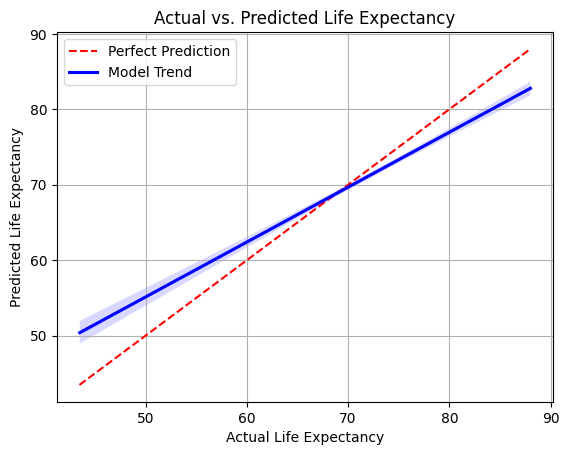

In [44]:
min_val = min(y_val.min(), y_pred.min())
max_val = max(y_val.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

# 3. Use seaborn to show the actual regression trend
sns.regplot(x=y_val, y=y_pred, scatter=False, color='blue', label='Model Trend')

# Formatting
plt.xlabel('Actual Life Expectancy')
plt.ylabel('Predicted Life Expectancy')
plt.title('Actual vs. Predicted Life Expectancy')
plt.legend()
plt.grid(True)
plt.show()